# <span style="color:red"> Lecture 14: User-defined Functions </span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## <span style="color:red"> I. Why Functions are Convenient </span>

<font size = "3">

A function is ...

- A **block of reusable** code to perform a specific task
- When we use functions we can ignore repetition
- As our code grows larger, functions make it more manageable

To motivate the need for functions, suppose we wanted to compute the median of 3 Numpy arrays. For each array, we could do the following:

1. Sort the Numpy array

2. If the length of the array is odd, extract the middle value of the array.

3. If the length of the array is even, extract the two middle values and calculate their mean.

We'll compute the medians of the following 3 arrays:

In [2]:
np.random.seed(158354304)
array_1 = np.random.normal(size = 100)
array_2 = np.random.normal(size = 97)
array_3 = np.random.normal(size = 120)

<font size = "3">
Which of the following two code cells do you prefer?

In [3]:
#### Code cell A

sorted_1 = array_1 
n = len(sorted_1)
for i in range(n-1):
    max_ind = None 
    max_val = -np.inf 
    for j in range(n-i):
        if sorted_1[j] > max_val:
            max_ind = j
            max_val = sorted_1[j]
    if max_ind != n-i-1:
        sorted_1[n-i-1],sorted_1[max_ind] = sorted_1[max_ind], sorted_1[n-i-1]

quotient, remainder = divmod(n, 2)
if remainder == 1:
    median_1 = sorted_1[quotient]
else:
    median_1 = (sorted_1[quotient] + sorted_1[quotient-1])/2

print("Median of first array:", median_1)

sorted_2 = array_2
n = len(sorted_2)
for i in range(n-1):
    max_ind = None 
    max_val = -np.inf 
    for j in range(n-i):
        if sorted_2[j] > max_val:
            max_ind = j
            max_val = sorted_2[j]
    if max_ind != n-i-1:
        sorted_2[n-i-1],sorted_2[max_ind] = sorted_2[max_ind], sorted_2[n-i-1]

quotient, remainder = divmod(n, 2)
if remainder == 1:
    median_2 = sorted_2[quotient]
else:
    median_2 = (sorted_2[quotient] + sorted_2[quotient-1])/2

print("Median of second array:", median_2)

sorted_3 = array_3
n = len(sorted_3)
for i in range(n-1):
    max_ind = None 
    max_val = -np.inf 
    for j in range(n-i):
        if sorted_3[j] > max_val:
            max_ind = j
            max_val = sorted_3[j]
    if max_ind != n-i-1:
        sorted_3[n-i-1],sorted_3[max_ind] = sorted_3[max_ind], sorted_3[n-i-1]

quotient, remainder = divmod(n, 2)
if remainder == 1:
    median_3 = sorted_3[quotient]
else:
    median_3 = (sorted_3[quotient] + sorted_3[quotient-1])/2

print("Median of third array:", median_3)

Median of first array: -0.0349554184048569
Median of second array: -0.07496938529974628
Median of third array: -0.2647016978775143


In [4]:
### Code cell B

median_1 = np.median(array_1)
print("Median of first array:", median_1)

median_2 = np.median(array_2)
print("Median of second array:", median_2)

median_3 = np.median(array_3)
print("Median of third array:", median_3)

Median of first array: -0.0349554184048569
Median of second array: -0.07496938529974628
Median of third array: -0.2647016978775143


<font size = "3">


I think we all prefer "Code cell B". The developers of NumPy wrote the function "numpy.median" to "wrap" all the commands necessary to compute the median.

But inevitably we will want to perform tasks that library developers haven't already created functions for. Then we will want to write our own **custom** functions.

## <span style="color:red"> II. Review of built-in functions </span>

<font size="3"> 

"Built-in" functions are those from Python libraries, e.g.

```print()```, ```type()```, ```round()```,```abs()```, ```len()```


- Inputs are known as "arguments"
- Outputs are known as "return values"

Let's look at the arguments and return values of some familiar functions (and some non-familiar functions)

##### `type` function

In [5]:
# Argument: a Python object
# Return value: the type or class of the object

# Here, the float 3.14 is the argument
# We assign the return value to a variable we call q
q = type(3.14)
print(q)
print()

# we can also assign 3.14 to a variable, then use this as the argument:

my_num = 3.14
qqqq = type(my_num)
print(qqqq)

print()

# Here, we don't assign the return value to a variable, we just print it

my_string = "March 2nd"
print(type(my_string))

<class 'float'>

<class 'float'>

<class 'str'>


##### `abs` function

In [6]:
# Argument: a single number (integer or floating point)
# Return value: a single number, which is the absolute value of the argument

tt = abs(3)

y = 2.2
s = abs(-y)

print(s)
print(tt)
print(abs(-10))


2.2
3
10


##### `len` function

In [7]:
# Argument: An "appropriate" python object (like a list, numpy array, or a string)
# Return value: How many items are in the object

my_argument = [1.0, "Hi", "2025"]
my_return_val = len(my_argument)
print(my_return_val)

str_1 = "Peter"
str_2 = "Peter "
num_letters = len(str_1)
print(num_letters)
print(len(str_2))

3
5
6


In [8]:
# An "inappropriate" object for len would be a single number:

my_arg = 2
print(len(my_arg))

TypeError: object of type 'int' has no len()

##### `str` function

In [ ]:
# Argument: Object
# Return value: Object converted to string

neg_num = -3
pos_num = abs(neg_num)
out_1 = str(pos_num)

out_2 = str(abs(neg_num) + 5)

print(out_1)
display(out_2)

3


'8'

In [ ]:
neg_num
abs(neg_num)
abs(neg_num) + 5
str(abs(neg_num) + 5)

'8'

##### `round` function

In [ ]:
# TWO arguments: one is optional.
# Argument 1: (required) a number
# Argument 2: (optional) number of digits to round to

# Return value: the rounded number. 
# (If the 2nd argument is omitted, rounded to an integer)

z = round(3.1415)
print(z)

zzz = round(3.1415, 3)
print(zzz)



3
3.142


In [ ]:
# The arguments of round are "named" (keywords)
help(round)

Help on built-in function round in module builtins:

round(number, ndigits=None)
    Round a number to a given precision in decimal digits.

    The return value is an integer if ndigits is omitted or None.  Otherwise
    the return value has the same type as the number.  ndigits may be negative.



In [ ]:
# Valid ways of calling the round function
z1 = round(3.1415, 3)
z2 = round(3.1415, ndigits=3)
z3 = round(number=3.1415, ndigits=3)

# invalid_output = round(number = 3.1415, 3) ## INVALID

print(z1)
print(z2)
print(z3)

3.142
3.142
3.142


In [ ]:
my_num = 3.1415
digits_I_want_to_keep = 3

z4 = round(my_num, digits_I_want_to_keep)
z5 = round(my_num, ndigits=digits_I_want_to_keep)
z6 = round(number=my_num, ndigits=digits_I_want_to_keep)

print(z4)
print(z5)
print(z6)

3.142
3.142
3.142


##### `print` function

In [ ]:
# Argument(s): 1 or more Python object. 
# (If more than one object, separate them by commas)

# Return values: None

t = print("Today", "is", "October", 1)
print(t) # This is None (print has no return value)

Today is October 1
None


##### `divmod` function (a new function)

In elementary school you might have performed division in the following way:

$$\frac{32}{5} = 6\ \textrm{remainder }2$$

(because $\frac{32}{5} = \frac{30}{5} + \frac{2}{5} = 6 + \frac{2}{5}$)

This is what the `divmod` function computes:

In [ ]:
# Arguments: 2 numbers

# Return value: A tuple containing the quotient and remainder

dividend = 32
divisor = 5

div_tuple = divmod(dividend, divisor)

print(div_tuple)
print(type(div_tuple))

quotient = div_tuple[0]
remainder = div_tuple[1]

print("Quotient:", quotient)
print("Remainder:", remainder)

(6, 2)
<class 'tuple'>
Quotient: 6
Remainder: 2


<font size = "3">

We can skip the intermediate tuple, and just assign the output to two separate variables:

In [ ]:
top_number = 32
bottom_number = 5

q, r = divmod(top_number, bottom_number)

print(type(q))
print(type(r))

print("Quotient:", q)
print("Remainder:", r)

<class 'int'>
<class 'int'>
Quotient: 6
Remainder: 2


<font size = "3">

Naming a variable "_" is a common way to ignore an output of a function if you're only interested in one.

In [ ]:
# If I ONLY care about the remainder

_, remainder = divmod(33, 11)

print("Remainder of 33/11 is:", remainder)

Remainder of 33/11 is: 0


In [ ]:
print(_)

3


## <span style="color:red"> III. What is a function? </span>

<font size = "3">

- In math, we are used to thinking of functions as formulas applied to single numbers like:
$$ y = f(x) = 2x + 1 $$
- This function could also be written as:
$$ f: q \mapsto r = 2q + 1$$
- In general, we can view a function as a process where we take a certain number of inputs, perform some tasks or computations with them, and return 1 or more outputs


Some examples:
- A function determining a country's GDP in 2023
    $$ f : \textrm{country} \mapsto \textrm{country's 2023 GDP in U.S. dollars}$$
    - $f(\textrm{United States}) = \textrm{\$ 27.7 trillion}$
    - $f(\textrm{Denmark}) = \textrm{\$ 407 billion}$
- A function that takes in a book's ISBN and returns its title:

    - $g(\textrm{979-8-37-616182-1}) = \textrm{Python Programming for Beginners}$

    - $g(\textrm{978-0-91-022751-3}) = \textrm{Autobiography of Malcolm X}$

Both of these examples have only 1 input and 1 output


<font size = "3">

Here is a very familiar example of a function. When you are told "Find the roots of the equation $ax^2 + bx + c = 0$", you are being instructed to compute the function

$$ q: (a, b, c) \mapsto (x_+, x_-)$$

Where the outputs $x_+$ and $x_-$ are defined using the quadratic formula:

$$ x_+ = \frac{-b + \sqrt{b^2 - 4ac}}{2a},\quad x_- = \frac{-b - \sqrt{b^2 - 4ac}}{2a}$$

## <span style="color:red"> IV. Custom Functions </span>

<font size = "3">

There is no built-in "quadratic formula" function in Python. But we can create one ourselves!

Similar to loops, sometimes it helps to plan things out before creating the function

In [ ]:
##### plan out the function


# define the input variables you want to pass into the function

# Start with the factored form of the polynomial,
# so you know what answer to expect:
# p(x) = 5(x + 1)(x + 2) has the roots -1, -2
# 
# 5(x + 1)(x + 2) = 5(x^2 + 3x + 2) = 5x^2 + 15x + 10
# So we can try a = 5, b = 15, c = 10
a = 5
b = 15
c = 10

############# beginning of function ###############

# perform necessary computations here
discrim = b**2 - 4*a*c
x_plus = -b + np.sqrt(discrim)
x_plus = x_plus/(2*a)

x_minus = -b - np.sqrt(discrim)
x_minus = x_minus/(2*a)
############# end of function ###############


# Then check that the outputs are correct

print(x_plus)
print(x_minus)

-1.0
-2.0


<font size = "3">

Now, let's create a function which computes the quadratic formula. We can name it whatever we like, but something sensible and descriptive is best

In [ ]:
# define quadratic formula function


# create function named "quadratic_formula" that has 3 input variables.
def quadratic_formula(a, b, c): 
    # just copy and paste code from the cell above
    discrim = b**2 - 4*a*c
    x_plus = -b + np.sqrt(discrim)
    x_plus = x_plus/(2*a)

    x_minus = -b - np.sqrt(discrim)
    x_minus = x_minus/(2*a)

    # return two values as output
    return x_plus, x_minus


In [ ]:
# Now test the function using same inputs
output = quadratic_formula(5, 15, 10)

print(type(output))
print(output[0])
print(output[1])

<class 'tuple'>
-1.0
-2.0


In [ ]:
# and new inputs...

# p(x) = -(x - 5)(x + 1/2) = -(x^2 - (9/2)x - 5/2) = -x^2 + (9/2)x + 5/2
# has the roots -0.5 and +5

a = -1
b = 9/2
c = 5/2

output = quadratic_formula(a, b, c)
print(output[0])
print(output[1])

-0.5
5.0


In [ ]:
# Name of Inputs don't matter!!!

coeff1 = -1
coeff2 = 9/2
coeff3 = 5/2

roots = quadratic_formula(coeff1, coeff2, coeff3)

print(roots[0])
print(roots[1])


-0.5
5.0


In [ ]:
# You can use the keywords when calling the function

# p(x) = 3(x - 5)(x - 1) = 3(x^2 - 6x + 5) = 3x^2 - 18x + 15

coeff1 = 3
coeff2 = -18
coeff3 = 15
x_plus, x_minus = quadratic_formula(a = coeff1, b = coeff2, c = coeff3)

print(x_plus)
print(x_minus)

5.0
1.0


In [ ]:
# You do not have to use the same name when assigning return values!

coeff1 = 3
coeff2 = -18
coeff3 = 15

# outputs don't have to be called "x_plus" and "x_minus"
root1, root2 = quadratic_formula(a = 3, b =  -18, c = 15)

print(root1)
print(root2)

5.0
1.0


<font size = "3">

There is no significance to the names we give the variables when defining the function (besides readability for humans)

For example, we could have defined the `quadratic_formula` function this way too:

In [ ]:
def quadratic_formula(input_1, input_2, input_3): 
    discrim = input_2**2 - 4*input_1*input_3
    output_1 = -input_2 + np.sqrt(discrim)
    output_1 = output_1/(2*input_1)

    output_2 = -input_2 - np.sqrt(discrim)
    output_2 = output_2/(2*input_1)

    return output_1, output_2


# test the function
root1, root2 = quadratic_formula(3, -18, 15)
print(root1)
print(root2)


5.0
1.0


<font size = "3">

**There is no unique way to write a function!**

Here are 4 equivalent ways we could have defined a function to compute the roots of a quadratic polynomial:

In [ ]:
def quad_f1(a, b, c):
    sqrt_d = np.sqrt(b**2 - 4*a*c) # compute sqrt of discriminant right away

    x_plus = -b + sqrt_d
    x_minus = -b - sqrt_d

    # divide x_plus and x_minus by 2*a, overwriting their values
    x_plus = x_plus/(2*a) # don't forget parentheses!!!
    x_minus = x_minus/(2*a)
    return x_plus, x_minus


def quad_f2(a, b, c):
    sqrt_d = np.sqrt(b**2 - 4*a*c)
    numer_plus = -b + sqrt_d
    numer_minus = -b - sqrt_d

    return numer_plus/(2*a), numer_minus/(2*a)

def quad_f3(a, b, c):
    sqrt_d = np.sqrt(b**2 - 4*a*c)
    return (-b + sqrt_d)/(2*a), (-b - sqrt_d)/(2*a)

# Would not recommend this one...
def quad_f4(a,b,c):
    return (-b + np.sqrt(b**2 - 4*a*c))/(2*a), (-b - np.sqrt(b**2 - 4*a*c))/(2*a)

<font size = "3">

In general functions take the form:

```python

    #---- DEFINE
    def my_function(parameter):
        body
        return expression

    #---- RUN
    my_function(parameter = argument) 

    #---- RUN
    my_function(argument)
```

<font size = "3">

For multiple arguments or multiple return values:
```python

    #---- DEFINE
    def my_function(parameter1, parameter2, parameter3):
        body
        return expression1, expression2

    #---- RUN
    my_function(parameter1 = arg1, parameter2 = arg2, parameter3 = arg3) 

    #---- RUN
    my_function(arg1, arg2, arg3)
```
<br>

## <span style="color:red"> V. Local vs. Global Variables </span>

<font size = "3">

All variables created inside the function that are not returned are **local variables**. They are **not** created in your workspace (those are **global variables**)

Let's restart the notebook, and use the quadratic formula function we created above:


In [ ]:
import numpy as np

def quadratic_formula(a, b, c):
    discrim = b**2 - 4*a*c
    x_plus = -b + np.sqrt(discrim)
    x_plus = x_plus/(2*a)

    x_minus = -b - np.sqrt(discrim)
    x_minus = x_minus/(2*a)
    return x_plus, x_minus

In [ ]:
c1 = 3
c2 = -18
c3 = 15

z_plus, z_minus = quadratic_formula(c1, c2, c3)

## <span style="color:red"> Exercises </span>

<font size = "3">

**Ex. 1** If we invest $P$ dollars in an account with interest rate $r$, compounded $n$ times yearly, then after $t$ years the account is worth:

$$V=P\left(1+{\frac {r}{n}}\right)^{nt}$$

Write a custom function that takes in the values of $P$, $r$, $n$, and $t$ and returns the final value $V$.

**Note**: For this formula, if the interest rate is 3%, then we would pass $r = 0.03$ into the function, not the number 3.

In [10]:
# your code here
def invest(P,r,n,t):
    a=1+(r/n)
    b=n*t
    V=P*(a**b)
    return V


<font size = "3">

Using your function, evaluate and print the final value if you invest $100$ dollars in an account with 1% interest rate, compounded 20 times a year, for 10 years 

In [11]:
# your code here
invest(100,0.01,20,10)


110.51432983541218

<font size = "3">

Using your function, evaluate and print the final value if you invest $1000$ dollars in an account with 5% interest rate, compounded 35 times a year, for 15 years

In [12]:
# your code here
invest(1000,0.05, 35,15)


2115.867291553817

<font size = "3">

**Ex. 2** Write a function that calculates
 $$f(x,y) = y+ x^2 + 2x + 1$$

In [ ]:
# your code here
def fun(x,y):
    x_sqr = x**2
    output = y+x_sqr+2*x+1
    return output


<font size = "3">

**Ex. 3** Write a function that calculates
 $$\mathbf{F}(x,y,z) = \begin{bmatrix} F_1(x,y,z)\\
 F_2(x,y,z) \\ F_3(x,y,z) \end{bmatrix} = \begin{bmatrix} x\mathrm{e}^y\\
 \mathrm{e}^{xy} \\ \sin(yz) \end{bmatrix}$$

You have a couple of choices here for the return value. 

- You could return a tuple of 3 floating point numbers.

- You could return a list of 3 floating point numbers.

- You could return a NumPy array of 3 floating point numbers (probably the best choice because mathematically, we are describing a vector).

If someone uses your function, are they able to define 3 separate floating point variables in one line when calling your function? Is this true for all 3 choices of the return value?

In [15]:
# Your code here
def F(x,y,z):
    return np.array([
        x*np.exp(y),
        np.exp(x*y),
        np.sin(y*z)
    ])


<font size = "3">

**Ex. 4** Write a function that calculates **two quantities**.

- First, it evaluates the vector-valued function

$$\mathbf{F}(x,y,z) = \begin{bmatrix} F_1(x,y,z)\\
 F_2(x,y,z) \\ F_3(x,y,z) \end{bmatrix} = \begin{bmatrix} x\mathrm{e}^y\\
 \mathrm{e}^{xy} \\ \sin(yz) \end{bmatrix}$$

- Second, it calculates the **divergence** of the function $\mathbf{F}$ (evaluated at the same values of $x$, $y$, and $z$):

$$\begin{align*}\nabla \cdot \mathbf{F} = \textrm{div } \mathbf{F} &= \frac{\partial F_1}{\partial x}(x,y,z) + \frac{\partial F_2}{\partial y}(x,y,z) + \frac{\partial F_3}{\partial x}(x,y,z)\\
&= \mathrm{e}^y + x\mathrm{e}^{xy} + y\cos(yz)\end{align*}$$

For the return value, it is important to keep the context in mind:

- The function returns **two** mathematical objects, the vector $\mathbf{F}$ and the number $\nabla \cdot \mathbf{F} = \textrm{div } \mathbf{F}$.

- We *could* choose to return 4 numbers, where 3 of them correspond to the components of $F_1$, $F_2$, $F_3$, and the other number corresponds to the value of $\textrm{div }\mathbf{F}$. But this wouldn't be a good idea, because this obscures the fact that $F_1$, $F_2$, and $F_3$ constitute a single mathematical object.

- So instead, return two values, one for the vector $\mathbf{F}$ and another for its divergence.

If someone uses your function, are they able to define 4 separate floating point variables in one line when calling your function? 

What happens if they assign the outputs to a single variable?

In [21]:
# your code here
def F_and_div(x,y,z):
    F=np.array([
        x*np.exp(y),
        np.exp(x*y),
        np.sin(y*z)
    ])
    divF = np.exp(y) + x*np.exp(x*y) + y*np.cos(y*z)
    return F, divF

# 4 separate floating point variables in one line
F_val, div_val = F_and_div(1,2,3)
f1,f2,f3 = F_val

# assign output to one variable
result = F_and_div(1,2,3)


<font size = "3">


**Ex. 5** Write **three** separate functions, corresponding to:

- $F_1(x,y,z) = x$
- $F_2(x,y,z) = y^2 z$
- $F_3(x,y,z) = xyz^3$

Then write an additional function corresponding to:

$$ \mathbf{F}(x,y,z) = \begin{bmatrix}F_1(x,y,z) \\ F_2(x,y,z) \\ F_3(x,y,z) \end{bmatrix} $$

Do **not** re-type any mathematical commands when creating the 4th function. This function should use the 3 component functions you wrote already.

In [22]:
# your code here
def F1(x,y,z):
    return x
def F2(x,y,z):
    return y**2*z
def F3(x,y,z):
    return x*y*z**3

def F(x,y,z):
    return[F1(x,y,z), F2(x,y,z), F3(x,y,z)]


<font size = "3">


**Ex. 6** Write a function that doesn't return any values (just like the `print` function).

The function takes in 3 arguments, with the following keywords:

- `vec_x`: A sequence of values (like a list, tuple, NumPy array, or column from a Pandas DataFrame).

- `xlabel`: A string

- `title`: A string

The function creates a histogram of the values in `vec_x`, labels the x-axis using the `xlabel` argument, always labels the y-axis with the string `"Frequency"`, and adds a title using the `title` argument. It then displays the histogram to the screen.

The function should have **no return values**. You can do this by having the last line of the function read `return None`. Or simply don't include a return statement at all.

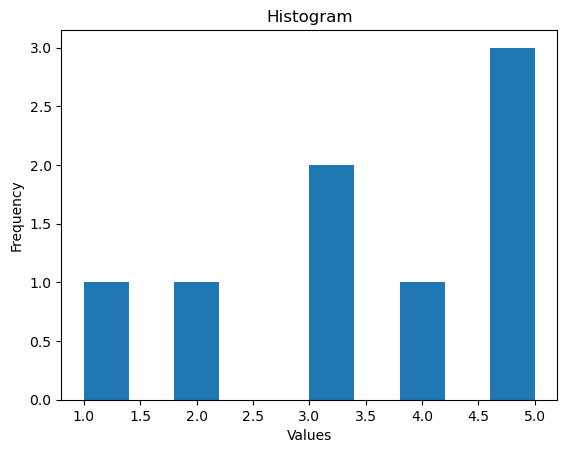

In [27]:
# complete the function
def create_histogram(vec_x, xlabel, title):
    plt.hist(vec_x)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

create_histogram([1,2,3,3,4,5,5,5],"Values","Histogram")

<font size = "3">


**Check:** If your code works, the next cell should display an appropriately labeled histogram. 

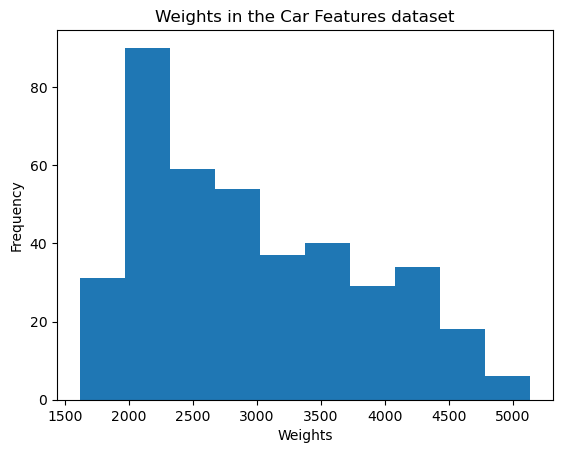

In [28]:
df = pd.read_csv("data/features.csv")

vector = df["weight"]
my_x_label = "Weights"
my_title = "Weights in the Car Features dataset"

create_histogram(vec_x = vector, xlabel = my_x_label, title = my_title)


<font size = "3">


**Check:** If your code works, the next cell should display **two** appropriately labeled histograms.

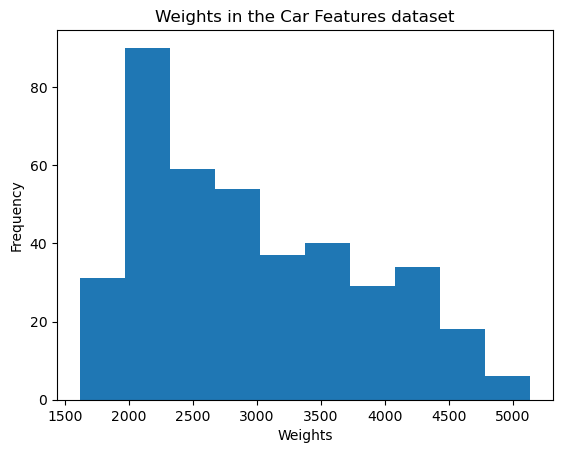

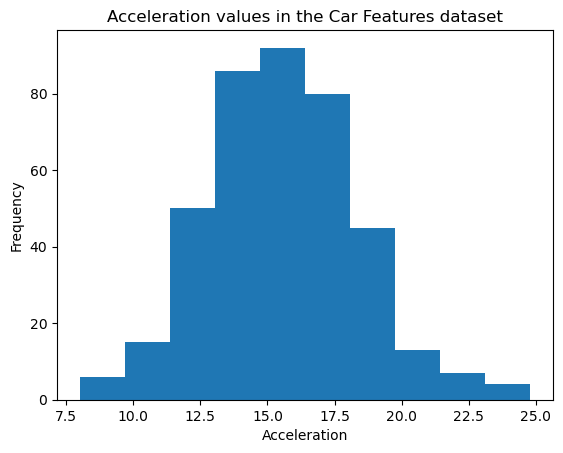

In [29]:
df = pd.read_csv("data/features.csv")

var1 = df["weight"]
label1 = "Weights" 
title1 = "Weights in the Car Features dataset"

var2 = df["acceleration"]
label2 = "Acceleration"
title2 = "Acceleration values in the Car Features dataset"

create_histogram(var1, label1, title1)
create_histogram(var2, label2, title2)

<font size = "3">


**Ex. 7** Write a function with one input argument with the keyword `numeric_grade`.

The function should return one string, depending on the value of `numeric_grade`:

- If `numeric_grade` is **greater than or equal to** 55, the return value should be the string `"status = pass"`

- Otherwise, the output value should be the string `"status = fail"`

In [31]:
# your code here
def test_grade(numeric_grade):
    if numeric_grade>=55:
        return "status=pass"
    else:
        return "status=fail"


<font size = "3">


**Ex. 8** Write a function with 3 arguments, 
 `first_name`, `last_name`, `car_model`

The function should return a single string reading:

"Dear customer {first_name} {last_name},
your {car_model} is ready for pickup".

(With appropriate substitutions for the words in curly brackets)

In [32]:
# your code here
def ready_message(first_name, last_name, car_model):
    return "Dear customer {first_name} {last_name}, your {car model} is ready for pickup"

<font size = "3">


**Ex. 9** Write a function named "check_voter_eligibility" which takes in a single integer `age` as an argument.

This function should check whether age $\ge$ 18, and return the corresponding Boolean value (`True` or `False`)

In [33]:
# your code here
def check_voter_eligibility(age):
    return age>=18

<font size = "3">

In the code cell below is a list containing the ages of 5 people.

Write a for loop which checks each age for voter eligibility using the function you just wrote.

At the end of the loop, you should have a list of length 5 where each element is either ``True`` or ``False``

In [34]:
list_ages = [18,29,15,32,6]

# your code here
results=[]
for age in list_ages:
    results.append(check_voter_eligibility(age))

print(results)

[True, True, False, True, False]
